# Preprocessing Approaches Visualization

This notebook visualizes the three preprocessing approaches side-by-side:
1. **Baseline**: Full-volume, no filtering
2. **Filtered Baseline**: Full-volume with lesion size filtering
3. **ROI-Cropped**: Adaptive crop/pad centered on tumor

Each view shows the tumor mask highlighted for comparison.

In [47]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import SimpleITK as sitk
import torchio as tio
from scipy.ndimage import zoom

# Ensure project modules (med3pipe) are on the path
project_root = Path().resolve().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from med3pipe.sam.transforms import ResizeLargestTo
from med3pipe.tabular.lesion_filter import LesionSizeFilter
from med3pipe.data.prepare import (
    find_case_dirs,
    find_image_files,
    find_segmentation_files,
    merge_images,
    merge_segmentations,
    resample_like,
    to_binary_mask,
)


In [48]:
SAM_TARGET_SIZE = 128
CLAMP_RANGE = (-1000, 1000)


def preprocess_ct_volume_for_baseline(sitk_img, target_size=SAM_TARGET_SIZE, clamp_range=CLAMP_RANGE):
    """Apply Clamp -> ToCanonical -> ResizeLargestTo -> CropOrPad."""
    tensor, affine = tio.data.io.sitk_to_nib(sitk_img)
    subject = tio.Subject(
        image=tio.ScalarImage(tensor=tensor, affine=affine)
    )
    transforms = tio.Compose([
        tio.Clamp(clamp_range[0], clamp_range[1]),
        tio.ToCanonical(),
        ResizeLargestTo(target_size=target_size),
        tio.CropOrPad(target_shape=(target_size, target_size, target_size)),
    ])
    subject = transforms(subject)
    return subject.image.data.squeeze().numpy().astype(np.float32)


def preprocess_mask_for_baseline(sitk_mask, target_size=SAM_TARGET_SIZE):
    tensor, affine = tio.data.io.sitk_to_nib(sitk_mask)
    subject = tio.Subject(
        label=tio.LabelMap(tensor=tensor, affine=affine)
    )
    transforms = tio.Compose([
        tio.ToCanonical(),
        ResizeLargestTo(target_size=target_size),
        tio.CropOrPad(target_shape=(target_size, target_size, target_size)),
    ])
    subject = transforms(subject)
    return subject.label.data.squeeze().numpy().astype(np.float32)


def crop_roi_from_baseline(volume, mask, margin=10, target_size=SAM_TARGET_SIZE):
    """Crop around tumor (on baseline volume) and resize back to target size."""
    coords = np.where(mask > 0)
    if coords[0].size == 0:
        # Fall back to centered crop if no lesion
        center = [s // 2 for s in volume.shape]
        z_min = max(0, center[0] - target_size // 4)
        z_max = min(volume.shape[0], center[0] + target_size // 4)
        y_min = max(0, center[1] - target_size // 4)
        y_max = min(volume.shape[1], center[1] + target_size // 4)
        x_min = max(0, center[2] - target_size // 4)
        x_max = min(volume.shape[2], center[2] + target_size // 4)
    else:
        z_min = max(0, int(coords[0].min()) - margin)
        z_max = min(volume.shape[0], int(coords[0].max()) + margin + 1)
        y_min = max(0, int(coords[1].min()) - margin)
        y_max = min(volume.shape[1], int(coords[1].max()) + margin + 1)
        x_min = max(0, int(coords[2].min()) - margin)
        x_max = min(volume.shape[2], int(coords[2].max()) + margin + 1)

    cropped_img = volume[z_min:z_max, y_min:y_max, x_min:x_max]
    cropped_mask = mask[z_min:z_max, y_min:y_max, x_min:x_max]

    # Resize cropped region back to target size
    zoom_factors = [target_size / s for s in cropped_img.shape]
    roi_img = zoom(cropped_img, zoom_factors, order=1)
    roi_mask = zoom(cropped_mask, zoom_factors, order=0)

    info = {
        "bbox": ((z_min, z_max), (y_min, y_max), (x_min, x_max)),
        "zoom": zoom_factors,
        "cropped_shape": cropped_img.shape,
    }
    return roi_img.astype(np.float32), roi_mask.astype(np.float32), info

In [49]:
# SAM-style display helpers (needed for any visualization cell downstream)
def compute_display_window(volume, modality="CT"):
    """Derive vmin/vmax from foreground voxels similar to SAM_Visualization."""
    vol = volume.astype(np.float32)
    vol_min = float(vol.min())
    vol_max = float(vol.max())
    threshold = vol_min + 0.05 * (vol_max - vol_min)
    fg_mask = vol > threshold
    if fg_mask.sum() > 100:
        fg_vals = vol[fg_mask]
        if "MR" in modality.upper():
            vmin, vmax = np.percentile(fg_vals, [1, 99])
        else:
            mu = float(fg_vals.mean())
            sd = float(fg_vals.std())
            vmin = max(mu - 2 * sd, float(fg_vals.min()))
            vmax = min(mu + 2 * sd, float(fg_vals.max()))
    else:
        vmin, vmax = vol_min, vol_max
    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-3
    return float(vmin), float(vmax)


def normalize_with_window(img_slice, window):
    """Clip slice to [vmin, vmax] window and rescale to [0, 1]."""
    vmin, vmax = window
    clipped = np.clip(img_slice, vmin, vmax)
    return (clipped - vmin) / (vmax - vmin + 1e-8)


## Configuration

Select a dataset and case to visualize.

In [50]:
# Dataset configuration - CHANGE THESE to your dataset paths
DATASET_ROOT = project_root / "data" / "gist"  # Change to your dataset path
CASE_GLOB = None  # Or specify pattern like "GIST-*_CT/1/NIFTI"

# Lesion filter configuration (for filtered baseline)
LESION_FILTER = LesionSizeFilter(
    min_voxels=100,
    min_dimension=3,
    min_density=0.1,
)

# ROI cropping configuration
ROI_MARGIN = 10  # voxels of context around tumor
ROI_TARGET_SIZE = 128  # final size after crop/pad

print(f"Dataset root: {DATASET_ROOT}")
print(f"Dataset exists: {DATASET_ROOT.exists()}")

Dataset root: C:\Users\cahel\Desktop\Med3Tab-PFN\data\gist
Dataset exists: True


## Discover Available Cases

List all prepared cases so we can pick one with a clearly visible tumor.

In [51]:
# Find all cases
case_dirs = find_case_dirs(DATASET_ROOT, case_glob=CASE_GLOB)

print(f"Found {len(case_dirs)} cases")
if case_dirs:
    print("\nFirst 5 cases:")
    for i, case_dir in enumerate(case_dirs[:5]):
        case_id = case_dir.parent.parent.name
        print(f"  {i}: {case_id}")
else:
    print("⚠️ No cases found! Check DATASET_ROOT path.")

Found 246 cases

First 5 cases:
  0: GIST-001_CT
  1: GIST-002_CT
  2: GIST-003_CT
  3: GIST-004_CT
  4: GIST-005_CT


## Find Best Slice with Maximum Tumor Visibility

Find the axial slice where the tumor has maximum area.

In [52]:
# Select a case to visualize
CASE_INDEX = 0  # Change this to select different case

if not case_dirs:
    raise ValueError("No cases found. Check DATASET_ROOT configuration.")

case_dir = case_dirs[CASE_INDEX]
case_id = case_dir.parent.parent.name

print(f"Selected case: {case_id}")
print(f"Case directory: {case_dir}")

# Load image and segmentation
image_files = find_image_files(case_dir)
seg_files = find_segmentation_files(case_dir)

if not image_files:
    raise ValueError(f"No image files found in {case_dir}")
if not seg_files:
    raise ValueError(f"No segmentation files found in {case_dir}")

print(f"\nFound {len(image_files)} image file(s)")
print(f"Found {len(seg_files)} segmentation file(s)")

# Merge multiple images/segmentations if present
img_sitk = merge_images(image_files)
seg_sitk = merge_segmentations(seg_files)

# Align image to segmentation geometry
if (img_sitk.GetSize() != seg_sitk.GetSize() or 
    img_sitk.GetSpacing() != seg_sitk.GetSpacing()):
    print("Resampling image to match segmentation geometry...")
    img_sitk = resample_like(img_sitk, reference=seg_sitk, is_label=False)

# Convert to binary mask
seg_sitk = to_binary_mask(seg_sitk)

# Raw arrays (before SAM preprocessing)
raw_img_array = sitk.GetArrayFromImage(img_sitk)  # Shape: (D, H, W)
raw_seg_array = sitk.GetArrayFromImage(seg_sitk)

print(f"\nRaw image shape: {raw_img_array.shape}")
print(f"Raw segmentation shape: {raw_seg_array.shape}")
print(f"Tumor voxels (raw): {raw_seg_array.sum()}")
print(f"Raw image range: [{raw_img_array.min():.1f}, {raw_img_array.max():.1f}]")

Selected case: GIST-001_CT
Case directory: C:\Users\cahel\Desktop\Med3Tab-PFN\data\gist\GIST-001_CT\1\NIFTI

Found 1 image file(s)
Found 1 segmentation file(s)

Raw image shape: (161, 512, 512)
Raw segmentation shape: (161, 512, 512)
Tumor voxels (raw): 1464862
Raw image range: [-2048.0, 1714.0]


In [53]:
# Apply SAM baseline preprocessing pipeline (Clamp -> ToCanonical -> ResizeLargestTo -> CropOrPad)
baseline_volume = preprocess_ct_volume_for_baseline(
    img_sitk,
    target_size=SAM_TARGET_SIZE,
    clamp_range=CLAMP_RANGE,
)
baseline_mask = preprocess_mask_for_baseline(
    seg_sitk,
    target_size=SAM_TARGET_SIZE,
)

baseline_img = baseline_volume.astype(np.float32)
baseline_seg = (baseline_mask > 0.5).astype(np.float32)
print(f"Baseline (SAM) volume shape: {baseline_volume.shape}")
print(f"Baseline (SAM) mask shape: {baseline_seg.shape}")

Baseline (SAM) volume shape: (128, 128, 128)
Baseline (SAM) mask shape: (128, 128, 128)


# Find slice with maximum tumor area on SAM baseline volume (AXIAL view)
# Shape is (X, Y, Z) -> We want to slice along Z (dim 2)
baseline_tumor_areas = baseline_seg.sum(axis=(0, 1))
best_slice_idx = int(np.argmax(baseline_tumor_areas))

print(f"Baseline volume shape (X, Y, Z): {baseline_seg.shape}")
print(f"Best slice index (Axial/Z): {best_slice_idx}")
print(f"Tumor area at best slice: {baseline_tumor_areas[best_slice_idx]} voxels")

# Bounding box within SAM-preprocessed volume
tumor_coords = np.where(baseline_seg > 0)
if len(tumor_coords[0]) == 0:
    raise ValueError("No tumor voxels found after preprocessing")

# coords are (x, y, z)
x_min, x_max = int(tumor_coords[0].min()), int(tumor_coords[0].max())
y_min, y_max = int(tumor_coords[1].min()), int(tumor_coords[1].max())
z_min, z_max = int(tumor_coords[2].min()), int(tumor_coords[2].max())

tumor_center = (
    (x_min + x_max) // 2,
    (y_min + y_max) // 2,
    (z_min + z_max) // 2,
)

print(f"\nTumor bounding box (baseline volume):")
print(f"  X (L-R): [{x_min}, {x_max}]")
print(f"  Y (P-A): [{y_min}, {y_max}]")
print(f"  Z (I-S): [{z_min}, {z_max}] <--- Slicing this dimension")
print(f"Tumor center: {tumor_center}")

## Preprocessing 1: Baseline (Full Volume)

Standard preprocessing - full CT volume, normalized.

In [54]:
# Check filtering on baseline SAM mask

def check_lesion_filter(seg, min_voxels=None, min_dimension=None, min_density=None, verbose=False):
    metrics = {}
    voxel_count = int(seg.sum())
    metrics['voxels'] = voxel_count
    coords = np.where(seg > 0)
    if len(coords[0]) == 0:
        dims = (0, 0, 0)
    else:
        dims = (
            int(coords[0].max() - coords[0].min() + 1),
            int(coords[1].max() - coords[1].min() + 1),
            int(coords[2].max() - coords[2].min() + 1),
        )
    metrics['dims'] = dims
    bbox_volume = np.prod(dims) if all(d > 0 for d in dims) else 0
    density = voxel_count / bbox_volume if bbox_volume > 0 else 0
    metrics['density'] = density
    passed = True
    reasons = []
    if min_voxels is not None and voxel_count < min_voxels:
        passed = False
        reasons.append(f"voxels {voxel_count} < {min_voxels}")
    if min_dimension is not None and (dims and min(dims) < min_dimension):
        passed = False
        reasons.append(f"min dimension {min(dims)} < {min_dimension}")
    if min_density is not None and density < min_density:
        passed = False
        reasons.append(f"density {density:.3f} < {min_density:.3f}")
    if verbose:
        print("\nLesion metrics:")
        print(f"  • Voxels: {voxel_count}")
        print(f"  • Bounding box dims: {dims}")
        print(f"  • Density: {density:.3f}")
        if reasons:
            print("  • Fails because: " + "; ".join(reasons))
    return passed

passes_filter = check_lesion_filter(
    baseline_seg,
    min_voxels=LESION_FILTER.min_voxels,
    min_dimension=LESION_FILTER.min_dimension,
    min_density=LESION_FILTER.min_density,
    verbose=True,
)

if passes_filter:
    print(f"\n✅ Case {case_id} PASSES lesion filter")
else:
    print(f"\n❌ Case {case_id} FAILS lesion filter")
    print("   (Would be excluded in filtered baseline)")


Lesion metrics:
  • Voxels: 22849
  • Bounding box dims: (60, 57, 17)
  • Density: 0.393

✅ Case GIST-001_CT PASSES lesion filter


In [55]:
# Display window helper (SAM-style)
def compute_display_window(volume, modality="CT"):
    """Derive vmin/vmax from foreground voxels similar to SAM_Visualization."""
    vol = volume.astype(np.float32)
    vol_min = float(vol.min())
    vol_max = float(vol.max())
    threshold = vol_min + 0.05 * (vol_max - vol_min)
    fg_mask = vol > threshold
    if fg_mask.sum() > 100:
        fg_vals = vol[fg_mask]
        if "MR" in modality.upper():
            vmin, vmax = np.percentile(fg_vals, [1, 99])
        else:
            mu = float(fg_vals.mean())
            sd = float(fg_vals.std())
            vmin = max(mu - 2 * sd, float(fg_vals.min()))
            vmax = min(mu + 2 * sd, float(fg_vals.max()))
    else:
        vmin, vmax = vol_min, vol_max
    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-3
    return float(vmin), float(vmax)


def normalize_with_window(img_slice, window):
    """Clip slice to [vmin, vmax] window and rescale to [0, 1]."""
    vmin, vmax = window
    clipped = np.clip(img_slice, vmin, vmax)
    return (clipped - vmin) / (vmax - vmin + 1e-8)


baseline_img = baseline_volume.astype(np.float32)
baseline_window = compute_display_window(baseline_img, modality="CT")

print(f"Baseline image shape (SAM pipeline): {baseline_img.shape}")
print(f"Baseline intensity range (clamped): [{baseline_img.min():.1f}, {baseline_img.max():.1f}]")
print(f"Display window (CT auto): [{baseline_window[0]:.1f}, {baseline_window[1]:.1f}]")


Baseline image shape (SAM pipeline): (128, 128, 128)
Baseline intensity range (clamped): [-1000.0, 1000.0]
Display window (CT auto): [-227.6, 215.2]


## Preprocessing 3: ROI-Cropped

Crop to tumor region with margin, then resize to target size.

In [56]:
if passes_filter:
    filtered_img = baseline_img.copy()
    filtered_seg = baseline_seg.copy()
    print("✅ Filtered baseline: Case included (same as baseline for this case)")
else:
    # Show what would happen - mark as excluded
    filtered_img = np.zeros_like(baseline_img)
    filtered_seg = np.zeros_like(baseline_seg)
    print("❌ Filtered baseline: Case would be EXCLUDED")

✅ Filtered baseline: Case included (same as baseline for this case)


## Visualization: Side-by-Side Comparison

Show all three preprocessing approaches with tumor masks overlaid.

In [57]:
# Prepare overlay slices for each preprocessing variant
from scipy.ndimage import zoom, rotate

def crop_to_roi(img, seg, margin=10, target_size=128):
    """Crop around tumor (on baseline volume) and resize back to target size."""
    coords = np.where(seg > 0)
    if coords[0].size == 0:
        center = [s // 2 for s in img.shape]
        x_min = max(0, center[0] - target_size // 4)
        x_max = min(img.shape[0], center[0] + target_size // 4)
        y_min = max(0, center[1] - target_size // 4)
        y_max = min(img.shape[1], center[1] + target_size // 4)
        z_min = max(0, center[2] - target_size // 4)
        z_max = min(img.shape[2], center[2] + target_size // 4)
    else:
        # coords[0]=X, coords[1]=Y, coords[2]=Z
        x_min = max(0, int(coords[0].min()) - margin)
        x_max = min(img.shape[0], int(coords[0].max()) + margin + 1)
        y_min = max(0, int(coords[1].min()) - margin)
        y_max = min(img.shape[1], int(coords[1].max()) + margin + 1)
        z_min = max(0, int(coords[2].min()) - margin)
        z_max = min(img.shape[2], int(coords[2].max()) + margin + 1)

    cropped_img = img[x_min:x_max, y_min:y_max, z_min:z_max]
    cropped_mask = seg[x_min:x_max, y_min:y_max, z_min:z_max]

    # Resize cropped region back to target size
    zoom_factors = [target_size / s for s in cropped_img.shape]
    roi_img = zoom(cropped_img, zoom_factors, order=1)
    roi_mask = zoom(cropped_mask, zoom_factors, order=0)

    info = {
        "bbox": ((x_min, x_max), (y_min, y_max), (z_min, z_max)),
        "zoom": zoom_factors,
        "cropped_shape": cropped_img.shape,
    }
    return roi_img.astype(np.float32), roi_mask.astype(np.float32), info

def ensure_roi_defined():
    global roi_img, roi_seg, crop_info, roi_window
    if all(name in globals() for name in ["roi_img", "roi_seg", "crop_info", "roi_window"]):
        return
    roi_img, roi_seg, crop_info = crop_to_roi(
        baseline_img,
        baseline_seg,
        margin=ROI_MARGIN,
        target_size=ROI_TARGET_SIZE,
    )
    roi_window = compute_display_window(roi_img, modality="CT")

def ensure_best_slice_defined():
    global best_slice_idx, tumor_center, x_min, x_max, y_min, y_max, z_min, z_max
    if 'best_slice_idx' in globals():
        return
    baseline_tumor_areas = baseline_seg.sum(axis=(0, 1))
    best_slice_idx = int(np.argmax(baseline_tumor_areas))
    tumor_coords = np.where(baseline_seg > 0)
    if len(tumor_coords[0]) == 0:
        raise ValueError("No tumor voxels found in baseline segmentation")
    x_min, x_max = int(tumor_coords[0].min()), int(tumor_coords[0].max())
    y_min, y_max = int(tumor_coords[1].min()), int(tumor_coords[1].max())
    z_min, z_max = int(tumor_coords[2].min()), int(tumor_coords[2].max())
    tumor_center = (
        (x_min + x_max) // 2,
        (y_min + y_max) // 2,
        (z_min + z_max) // 2,
    )

def overlay_mask(img_slice, seg_slice, window, alpha=0.35):
    # img_slice is (X, Y). We want standard Axial orientation.
    # 1. Transpose -> (Y, X)
    # 2. Rotate 90 deg if needed.
    # Standard imshow origin='upper'.
    # Let's just Transpose first. (Y, X).
    # Then Y is vertical (rows), X is horizontal (cols).
    # If Y is P-A, then P is top (0), A is bottom (max).
    # Standard CT: Anterior is UP. So we might need to flip Y.
    # Let's try Transpose + Rot90 to get it right.
    
    # Transpose (X, Y) -> (Y, X)
    img_t = img_slice.T
    seg_t = seg_slice.T
    
    # Flip Y (dim 0) to put Anterior (max Y) at top?
    # Depends on RAS+. Let's stick to simple Transpose first.
    # Actually, standard practice: just rotate 90 deg counter-clockwise often works.
    # Let's assume simple Transpose + FlipUD (rotate 90 deg).
    img_disp = np.rot90(img_slice)
    seg_disp = np.rot90(seg_slice)

    img_norm = normalize_with_window(img_disp, window)
    rgb = np.stack([img_norm, img_norm, img_norm], axis=-1)
    mask = seg_disp > 0.5
    rgb[mask, 0] = alpha + (1 - alpha) * rgb[mask, 0]
    rgb[mask, 1] = (1 - alpha) * rgb[mask, 1]
    rgb[mask, 2] = (1 - alpha) * rgb[mask, 2]
    return np.clip(rgb, 0, 1)

ensure_roi_defined()
ensure_best_slice_defined()

# Slice Dimension 2 (Z)
baseline_slice = baseline_img[:, :, best_slice_idx]
baseline_seg_slice = baseline_seg[:, :, best_slice_idx]
baseline_overlay = overlay_mask(baseline_slice, baseline_seg_slice, baseline_window)

filtered_slice = filtered_img[:, :, best_slice_idx]
filtered_seg_slice = filtered_seg[:, :, best_slice_idx]
filtered_overlay = overlay_mask(filtered_slice, filtered_seg_slice, baseline_window)

# Map Z-slice to ROI
z_bbox = crop_info["bbox"][2]  # Z-range
if z_bbox[0] <= best_slice_idx < z_bbox[1]:
    roi_slice_original = best_slice_idx - z_bbox[0]
    roi_slice_idx = int(roi_slice_original * crop_info["zoom"][2])
    roi_slice_idx = min(roi_slice_idx, roi_img.shape[2] - 1)
else:
    roi_slice_idx = roi_img.shape[2] // 2

roi_slice = roi_img[:, :, roi_slice_idx]
roi_seg_slice = roi_seg[:, :, roi_slice_idx]
roi_overlay = overlay_mask(roi_slice, roi_seg_slice, roi_window)

print(f"Slice indices (Axial/Z) -> baseline: {best_slice_idx}, filtered: {best_slice_idx}, ROI: {roi_slice_idx}")

Slice indices (Axial/Z) -> baseline: 49, filtered: 49, ROI: 64


## Visualization: Side-by-Side Comparison

Show all three preprocessing approaches with tumor masks overlaid.

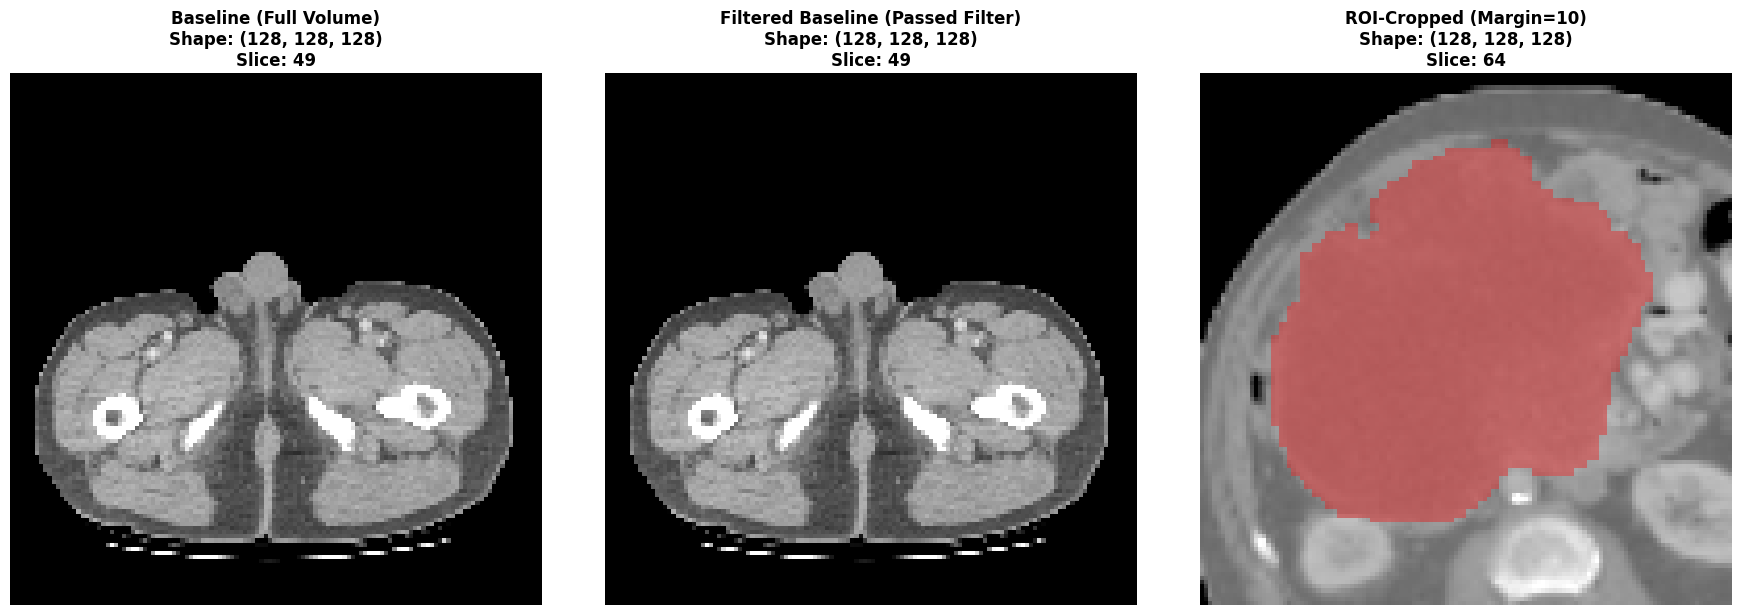


✅ Figure saved to: C:\Users\cahel\Desktop\Med3Tab-PFN\images\preprocessing_comparison\GIST-001_CT_comparison.png


In [58]:
# Plot side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Baseline
axes[0].imshow(baseline_overlay)
axes[0].set_title(
    f'Baseline (Full Volume)\nShape: {baseline_img.shape}\nSlice: {best_slice_idx}',
    fontsize=12,
    fontweight='bold'
)
axes[0].axis('off')

# Filtered Baseline
if passes_filter:
    axes[1].imshow(filtered_overlay)
    axes[1].set_title(
        f'Filtered Baseline (Passed Filter)\nShape: {filtered_img.shape}\nSlice: {best_slice_idx}',
        fontsize=12,
        fontweight='bold'
    )
else:
    axes[1].imshow(filtered_overlay, cmap='gray')
    axes[1].set_title(
        'Filtered Baseline (EXCLUDED)\nWould not be used in training',
        fontsize=12,
        fontweight='bold',
        color='red'
    )
axes[1].axis('off')

# ROI-Cropped
axes[2].imshow(roi_overlay)
axes[2].set_title(
    f'ROI-Cropped (Margin={ROI_MARGIN})\nShape: {roi_img.shape}\nSlice: {roi_slice_idx}',
    fontsize=12,
    fontweight='bold'
)
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Save figure
output_dir = project_root / 'images' / 'preprocessing_comparison'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f'{case_id}_comparison.png'
fig.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"\n✅ Figure saved to: {output_path}")

## Summary Statistics

Compare key characteristics of each preprocessing approach.

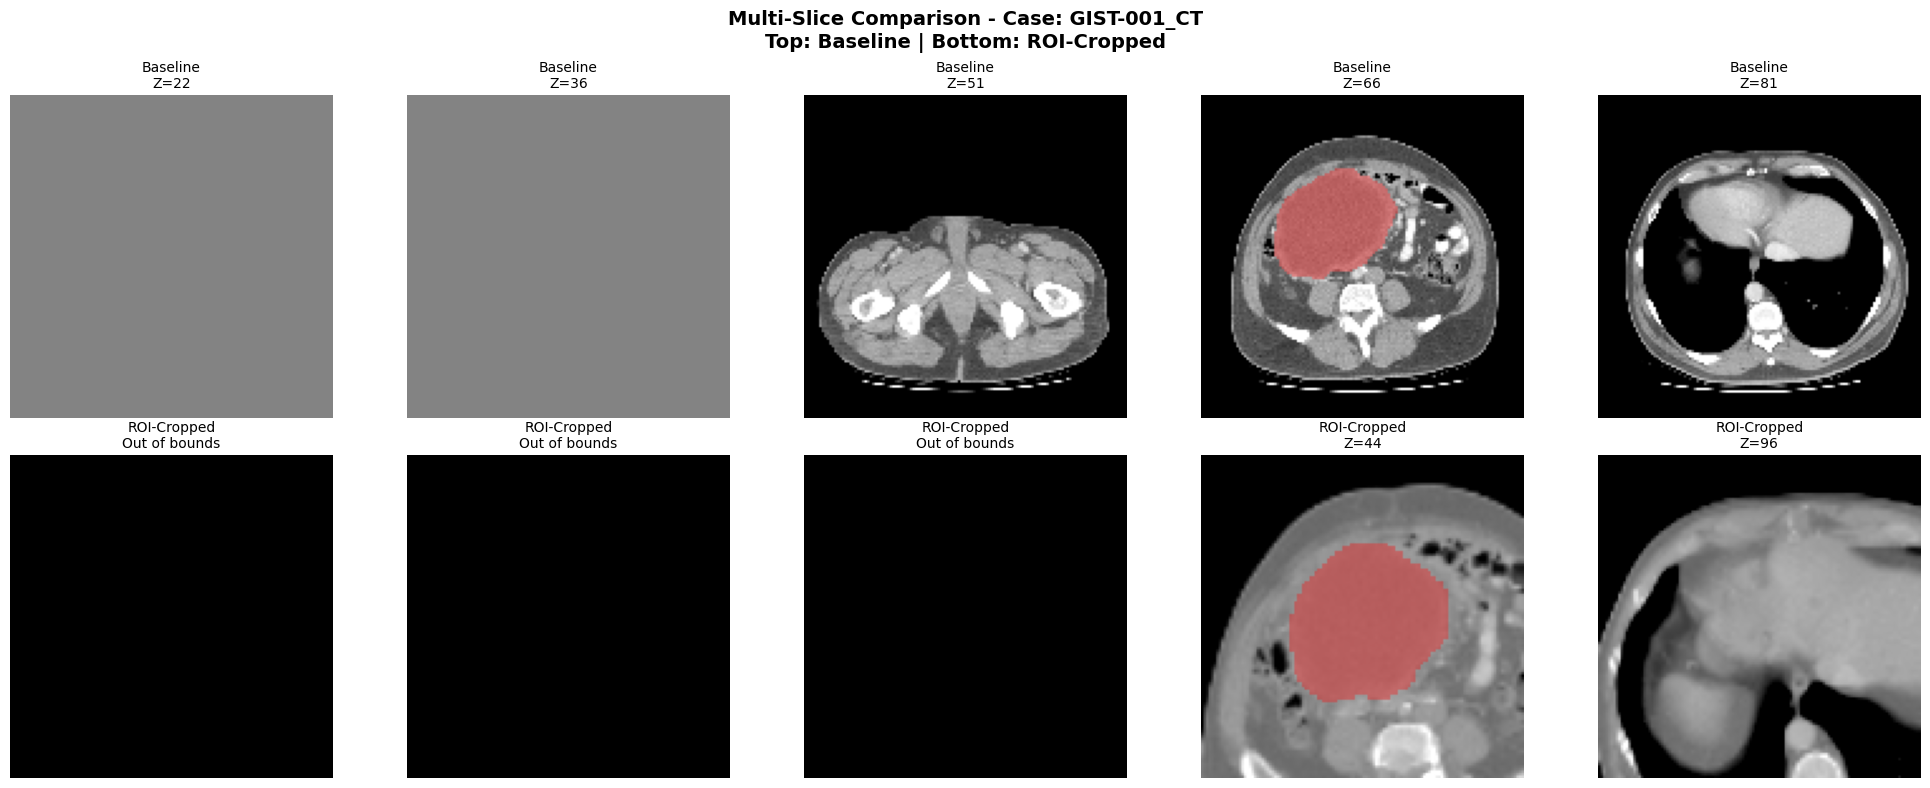

✅ Multi-slice figure saved to: C:\Users\cahel\Desktop\Med3Tab-PFN\images\preprocessing_comparison\GIST-001_CT_multislice_comparison.png


In [60]:
# Select 5 slices through the tumor (Axial/Z-axis)
n_slices = 5
slice_indices = np.linspace(z_min, z_max, n_slices, dtype=int)

fig, axes = plt.subplots(2, n_slices, figsize=(20, 8))

for i, slice_idx in enumerate(slice_indices):
    # Baseline (slice Z axis)
    baseline_sl = baseline_img[:, :, slice_idx]
    baseline_seg_sl = baseline_seg[:, :, slice_idx]
    baseline_ov = overlay_mask(baseline_sl, baseline_seg_sl, baseline_window)
    
    axes[0, i].imshow(baseline_ov)
    axes[0, i].set_title(f'Baseline\nZ={slice_idx}', fontsize=10)
    axes[0, i].axis('off')
    
    # ROI - map to ROI coordinates (Z axis)
    z_bbox = crop_info["bbox"][2]
    if z_bbox[0] <= slice_idx < z_bbox[1]:
        roi_slice_original = slice_idx - z_bbox[0]
        roi_slice_idx = int(roi_slice_original * crop_info['zoom'][2])
        roi_slice_idx = min(roi_slice_idx, roi_img.shape[2] - 1)
        
        roi_sl = roi_img[:, :, roi_slice_idx]
        roi_seg_sl = roi_seg[:, :, roi_slice_idx]
        roi_ov = overlay_mask(roi_sl, roi_seg_sl, roi_window)
        
        axes[1, i].imshow(roi_ov)
        axes[1, i].set_title(f'ROI-Cropped\nZ={roi_slice_idx}', fontsize=10)
    else:
        axes[1, i].imshow(np.zeros_like(baseline_ov))
        axes[1, i].set_title(f'ROI-Cropped\nOut of bounds', fontsize=10)
    axes[1, i].axis('off')

fig.suptitle(f'Multi-Slice Comparison - Case: {case_id}\nTop: Baseline | Bottom: ROI-Cropped',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Save
output_path_multi = output_dir / f'{case_id}_multislice_comparison.png'
fig.savefig(output_path_multi, dpi=150, bbox_inches='tight')
print(f"✅ Multi-slice figure saved to: {output_path_multi}")

## Try Different Cases

Re-run from the "Select a case" cell above with different `CASE_INDEX` to compare multiple cases.

In [61]:
import pandas as pd

summary = pd.DataFrame([
    {
        'Preprocessing': 'Baseline',
        'Shape': baseline_img.shape,
        'Total Voxels': np.prod(baseline_img.shape),
        'Tumor Voxels': baseline_seg.sum(),
        'Tumor %': f"{100 * baseline_seg.sum() / np.prod(baseline_img.shape):.3f}%",
        'Included': '✅ Yes',
    },
    {
        'Preprocessing': 'Filtered Baseline',
        'Shape': filtered_img.shape,
        'Total Voxels': np.prod(filtered_img.shape),
        'Tumor Voxels': filtered_seg.sum(),
        'Tumor %': f"{100 * filtered_seg.sum() / np.prod(filtered_img.shape):.3f}%" if passes_filter else 'N/A',
        'Included': '✅ Yes' if passes_filter else '❌ No (filtered out)',
    },
    {
        'Preprocessing': 'ROI-Cropped',
        'Shape': roi_img.shape,
        'Total Voxels': np.prod(roi_img.shape),
        'Tumor Voxels': roi_seg.sum(),
        'Tumor %': f"{100 * roi_seg.sum() / np.prod(roi_img.shape):.3f}%",
        'Included': '✅ Yes',
    },
])

print("\n" + "="*80)
print(f"PREPROCESSING COMPARISON SUMMARY - Case: {case_id}")
print("="*80)
print(summary.to_string(index=False))
print("="*80)

print("\n📊 Key Observations:")
print(f"  • Baseline uses full {baseline_img.shape} volume")
print(f"  • ROI-Cropped reduces to {roi_img.shape} (focused on tumor)")
print(f"  • Tumor percentage in ROI: {100 * roi_seg.sum() / np.prod(roi_img.shape):.1f}% vs Baseline: {100 * baseline_seg.sum() / np.prod(baseline_img.shape):.3f}%")
print(f"  • Volume reduction: {100 * (1 - np.prod(roi_img.shape) / np.prod(baseline_img.shape)):.1f}%")


PREPROCESSING COMPARISON SUMMARY - Case: GIST-001_CT
    Preprocessing           Shape  Total Voxels  Tumor Voxels Tumor % Included
         Baseline (128, 128, 128)       2097152       22849.0  1.090%    ✅ Yes
Filtered Baseline (128, 128, 128)       2097152       22849.0  1.090%    ✅ Yes
      ROI-Cropped (128, 128, 128)       2097152      215401.0 10.271%    ✅ Yes

📊 Key Observations:
  • Baseline uses full (128, 128, 128) volume
  • ROI-Cropped reduces to (128, 128, 128) (focused on tumor)
  • Tumor percentage in ROI: 10.3% vs Baseline: 1.090%
  • Volume reduction: 0.0%


## Try Different Cases

Re-run from the "Select a case" cell above with different `CASE_INDEX` to compare multiple cases.

In [62]:
print("\n💡 To visualize different cases:")
print("   1. Go back to 'Select a case to visualize' cell")
print("   2. Change CASE_INDEX value (0 to {})" .format(len(case_dirs) - 1))
print("   3. Re-run all cells from that point")
print("\n📁 All figures saved to:", output_dir)


💡 To visualize different cases:
   1. Go back to 'Select a case to visualize' cell
   2. Change CASE_INDEX value (0 to 245)
   3. Re-run all cells from that point

📁 All figures saved to: C:\Users\cahel\Desktop\Med3Tab-PFN\images\preprocessing_comparison
